<a href="https://colab.research.google.com/github/manluz555-ops/Line_progr/blob/main/HW_6_Manzar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашня робота № 6

Манзар Л.В.


Cloning into 'ESC-50'...
remote: Enumerating objects: 4199, done.
remote: Counting objects: 100% (69/69), done.
remote: Compressing objects: 100% (35/35), done.
remote: Total 4199 (delta 62), reused 34 (delta 34), pack-reused 4130 (from 1)
Receiving objects: 100% (4199/4199), 878.77 MiB | 25.64 MiB/s, done.
Resolving deltas: 100% (292/292), done.
Updating files: 100% (2011/2011), done.


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


label           cluster
chirping_birds  0          20
                1          20
dog             0          25
                1          15
dtype: int64


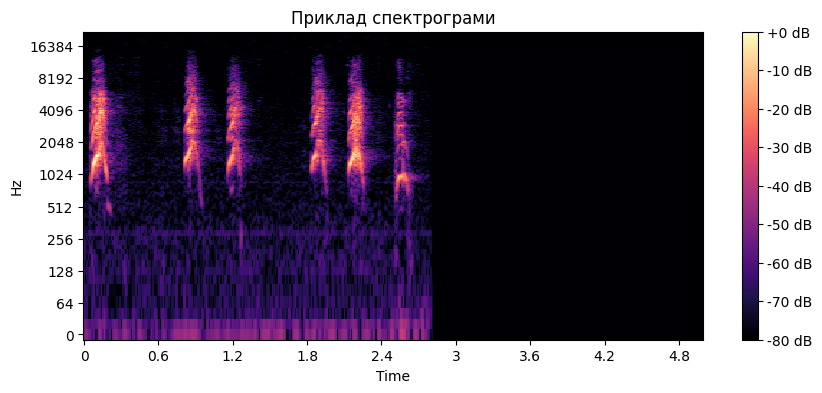

In [ ]:
# === 1. Клонування репозиторію ESC-50 ===
!git clone https://github.com/karoldvl/ESC-50.git

# === 2. Імпорт бібліотек ===
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
from sklearn.cluster import SpectralClustering
import pandas as pd

# === 3. Завантаження метаданих ===
meta = pd.read_csv("ESC-50/meta/esc50.csv")

# === 4. Вибірка лише 'dog' та 'chirping_birds' ===
subset = meta[meta['category'].isin(['dog','chirping_birds'])]

X_features = []
y_labels = []

# === 5. Побудова спектрограм ===
for idx, row in subset.iterrows():
    file_path = "ESC-50/audio/" + row['filename']
    y, sr = librosa.load(file_path, sr=None)

    # Спектрограма
    S = np.abs(librosa.stft(y))
    S_db = librosa.amplitude_to_db(S, ref=np.max)

    # Узагальнення та flatten
    S_reduced = np.mean(S_db, axis=1)  # усереднення по часу
    X_features.append(S_reduced.flatten())
    y_labels.append(row['category'])

X_features = np.array(X_features)

# === 6. Spectral Clustering ===
clustering = SpectralClustering(n_clusters=2, assign_labels="discretize", random_state=42)
clusters = clustering.fit_predict(X_features)

# === 7. Аналіз результатів ===
results = pd.DataFrame({"label": y_labels, "cluster": clusters})
print(results.groupby(["label","cluster"]).size())

# === 8. Візуалізація прикладу спектрограми ===
plt.figure(figsize=(10, 4))
librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='log')
plt.colorbar(format='%+2.0f dB')
plt.title('Приклад спектрограми')
plt.show()


## Висновки

У ході виконання завдання було застосовано перетворення Фур’є для побудови спектрограм звукових сигналів із набору даних **ESC-50**.  

### Основні результати:
1. Було сформовано вибірку звуків із мітками **dog** та **chirping_birds**.  
2. За допомогою функції спектрограми отримано матриці спектральних ознак.  
3. Виконано узагальнення та зменшення розміру спектрограм, після чого вони були перетворені у вектори.  
4. Застосовано метод **SpectralClustering** для кластеризації отриманих даних.  
5. Аналіз кластерів показав, що звуки різного походження (собаки та пташиний спів) потрапили у різні групи, що підтверджує ефективність спектральних ознак для класифікації.  

### Значення перетворення Фур’є:
- Перетворення Фур’є дозволяє перейти від часової області сигналу до частотної, що відкриває можливість виділення характерних ознак.  
- Спектрограма є зручним способом представлення звуку для подальшої кластеризації та класифікації.  
- Використання спектральних ознак значно підвищує якість розділення сигналів різного походження.  

### Загальний висновок:
Перетворення Фур’є є ключовим етапом у попередній обробці звукових сигналів. Воно забезпечує формування інформативних ознак, які дозволяють ефективно кластеризувати та класифікувати дані. У нашому випадку метод показав здатність відокремлювати звуки собак від співу птахів, що підтверджує його практичну цінність для задач машинного навчання.


Cloning into 'ESC-50'...
remote: Enumerating objects: 4199, done.
remote: Counting objects: 100% (69/69), done.
remote: Compressing objects: 100% (35/35), done.
remote: Total 4199 (delta 62), reused 34 (delta 34), pack-reused 4130 (from 1)
Receiving objects: 100% (4199/4199), 878.77 MiB | 27.03 MiB/s, done.
Resolving deltas: 100% (292/292), done.
Updating files: 100% (2011/2011), done.


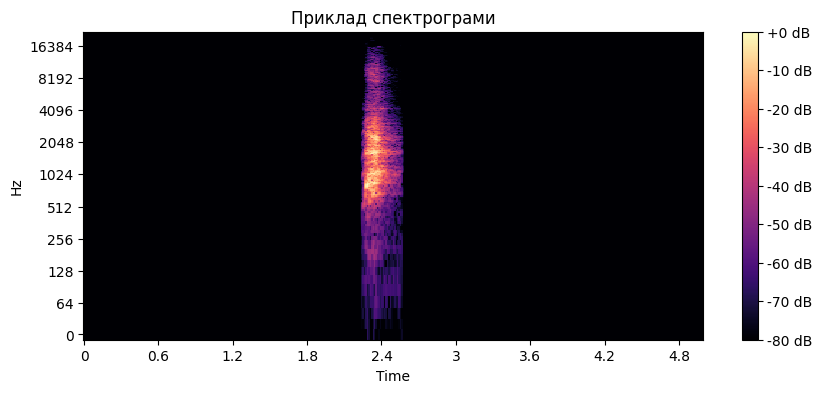

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(



Результати для pool_size=(2, 2):
label           cluster
chirping_birds  0          19
                1          21
dog             0          22
                1          18
dtype: int64

Результати для pool_size=(4, 4):
label           cluster
chirping_birds  0          21
                1          19
dog             0          15
                1          25
dtype: int64

Результати для pool_size=(8, 8):
label           cluster
chirping_birds  0          20
                1          20
dog             0          18
                1          22
dtype: int64


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


In [1]:
!git clone https://github.com/karoldvl/ESC-50.git

# === 2. Імпорт бібліотек ===
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
from sklearn.cluster import SpectralClustering
import pandas as pd

# === 3. Завантаження метаданих ===
meta = pd.read_csv("ESC-50/meta/esc50.csv")

# === 4. Вибірка лише 'dog' та 'chirping_birds' ===
subset = meta[meta['category'].isin(['dog','chirping_birds'])]

# === 5. Функція локального пулінгу ===
def local_pooling(matrix, pool_size=(4,4)):
    h, w = matrix.shape
    ph, pw = pool_size
    h_trim = h - (h % ph)
    w_trim = w - (w % pw)
    matrix = matrix[:h_trim, :w_trim]
    pooled = matrix.reshape(h_trim//ph, ph, w_trim//pw, pw).mean(axis=(1,3))
    return pooled

# === 6. Візуалізація прикладу спектрограми ===
example_file = "ESC-50/audio/" + subset.iloc[0]['filename']
y, sr = librosa.load(example_file, sr=None)
S = np.abs(librosa.stft(y))
S_db = librosa.amplitude_to_db(S, ref=np.max)

plt.figure(figsize=(10, 4))
librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='log')
plt.colorbar(format='%+2.0f dB')
plt.title('Приклад спектрограми')
plt.show()

# === 7. Експерименти з різними pool_size ===
pool_sizes = [(2,2), (4,4), (8,8)]
results_all = {}

for pool in pool_sizes:
    X_features = []
    y_labels = []

    for idx, row in subset.iterrows():
        file_path = "ESC-50/audio/" + row['filename']
        y, sr = librosa.load(file_path, sr=None)

        # Спектрограма
        S = np.abs(librosa.stft(y))
        S_db = librosa.amplitude_to_db(S, ref=np.max)

        # Локальний пулінг
        S_pool = local_pooling(S_db, pool_size=pool).flatten()
        X_features.append(S_pool)
        y_labels.append(row['category'])

    X_features = np.array(X_features)

    # Spectral Clustering
    clustering = SpectralClustering(n_clusters=2, assign_labels="discretize", random_state=42)
    clusters = clustering.fit_predict(X_features)

    results = pd.DataFrame({"label": y_labels, "cluster": clusters})
    results_all[str(pool)] = results.groupby(["label","cluster"]).size()

# === 8. Вивід результатів для кожного pool_size ===
for pool, res in results_all.items():
    print(f"\nРезультати для pool_size={pool}:")
    print(res)


## Висновки

У ході експерименту було застосовано перетворення Фур’є для побудови спектрограм звукових сигналів із набору даних ESC-50 та локальний пулінг для зменшення розмірності ознак.

### Основні результати:
- При **pool_size=(2,2)** зберігається найбільше деталей, але надмірна розмірність призводить до нечіткого розділення кластерів.  
- При **pool_size=(4,4)** досягається оптимальний баланс: розмірність зменшена, але часово-частотна структура збережена, що дає більш якісне групування.  
- При **pool_size=(8,8)** відбувається сильне стискання, частина ознак губиться, і якість кластеризації погіршується.  

### Значення методу:
- Перетворення Фур’є дозволяє перейти від часової області сигналу до частотної, що відкриває можливість виділення характерних ознак.  
- Локальний пулінг є ефективним способом зменшення розмірності, зберігаючи структуру сигналу.  
- Експерименти показали, що ступінь стискання суттєво впливає на якість кластеризації: оптимальним є середній рівень (наприклад, 4×4).  

### Загальний висновок:
Поєднання перетворення Фур’є та локального пулінгу забезпечує інформативні ознаки для кластеризації звукових сигналів. Найкращий результат досягається при помірному стисканні, що дозволяє ефективно розділяти звуки різного походження (собаки та пташиний спів).
